<font size="5">**Modulo — Il percorso del dato nell'osservabilità**</font><br>

> Corso Python per sistemisti: · formati grezzi · tempo · correlazioni tra KPI · database relazionali · Splunk

> (c) 2026 Antonio Piemontese

Seguiamo un dato lungo tutta la sua vita in un sistema di osservabilità, dai file grezzi fino a
Splunk, e nel mezzo lo **analizziamo**. Cinque anelli concatenati:

1. **Leggere i formati grezzi** (1.2) — il *lettore ai bordi* che da log e file produce record puliti.
2. **Ordinare nel tempo** (1.3) — timestamp eterogenei, fusi orari, e la *correlazione temporale*.
3. **Correlare i KPI** — quali metriche si muovono insieme, con che intensità, e con quale *ritardo*.
4. **Attingere ai database** (2.1) — il pattern DB-API 2.0, uguale per SQLite, Oracle e SQL Server.
5. **Chiudere il cerchio con Splunk** (3.2) — estrarre i risultati di ricerca e rispedire metriche.

Il filo è quello del Modulo 1.1: *acquisire ai bordi → elaborare con strumenti dedicati*. Come per i
database, **Splunk e Oracle/SQL Server sono simulati** (niente rete): ne mostriamo il pattern con dati
di esempio e codice di riferimento, mentre tutto il resto gira davvero su SQLite e file locali.

In [1]:
# impostazione del TOGGLE BINARIO:
try:
    import google.colab                      # package disponibile SOLO in Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)


# IMPORT dei package necessari (necessari sia in VSC che in Colab perle IMMAGINI):
from IPython.display import Image, display   # import dei package di incorporamento e visualizzazione immagine (una tantum)
                                             # Image e display sono entrambi necessari a Jupyter Notebook
                                             # Google Colab utilizza solo Image
import os                                    # necessario a Google Colab per vedere da una cella codice
                                             # i contenuti del 'content'

Running on Colab: True


# Legenda delle icone (standard)
Legenda delle icone (standard) usate nel notebook (per garantire consistenza semantica):

👉 punto di attenzione, il "succo"<br>
📌 nota / inizio di una nota<br>
📦 punto elenco importante<br>
📊 dati/numeri<br>
🔹 punto elenco normale<br>
⭐ punto elenco importante<br>
✅ punto risolto, positivo<br>
❌ punto negativo, da evitare<br>
⚠️ attenzione, warning, allarme<br>
💡 idea chiave<br>
🧠 idea intuitiva<br>
📝 sintesi / bottom-line<br>
⟶ conseguenza, effetto, passo successivo

# Immagini

* `regex.png`
* `regex2.png`
* `regex3.png`

# Preparazione dei dati

Generiamo **14 giorni di metriche orarie** con una struttura **realistica**: un ciclo giorno/notte nel
volume di richieste, che trascina CPU e latenza, con la latenza che reagisce al carico con un
**ritardo di circa un'ora** (ci servirà per la cross-correlazione). Su questo sfondo iniettiamo un
**incidente**: un picco anomalo di latenza ed errori il 7 giugno alle 16 (UTC), accompagnato da un
**burst di errori** nel log applicativo. Generiamo anche un log di sistema e un export CSV.

Il seguente diagramma visualizza l'organizzazione della preparazione dei dati:

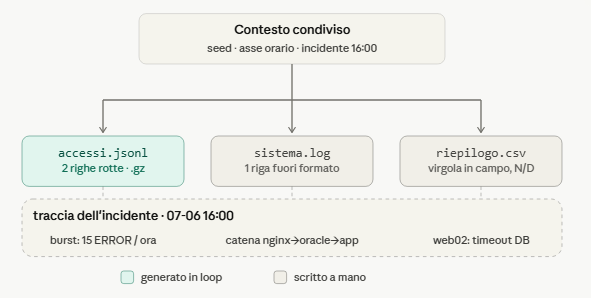

In [2]:
Image('PGD.png') if IN_COLAB else display(Image(filename='regex.png'))

Vediamo **le due modalità di generazione** usate da questo processo generativo dei dati.

---
**Generato in loop** (color verde nel diagramma)

Significa che il contenuto del file viene costruito **programmaticamente**, facendo girare un ciclo (`for`) che produce le righe una a una, secondo una logica. Non scriviamo noi le singole righe: scriviamo la *regola* che le genera, e il ciclo le sforna. È il caso di `accessi.jsonl`:

```python
  righe = []
  for t in ts:                                    # ciclo su tutte le ore
      for _ in range(15 if incidente else 2):     # n eventi, deciso da una condizione
          istante = t + timedelta(minutes=random.randint(0, 59))   # valore casuale
          ...
          righe.append(json.dumps({...}))         # costruisce la riga e la accumula
```

Le caratteristiche che lo definiscono: c'è un **ciclo** che ripete; il numero e il contenuto delle righe sono **decisi da logica** (`15 if incidente else 2`) e da **casualità** (`random.randint`, `random.choice`); e il risultato **dipende dai dati a monte** (l'asse temporale `ts`, l'ora dell'incidente). Le 685 righe del JSONL non sono state digitate da nessuno: sono il prodotto di quella regola eseguita 336 volte. Se cambiassi il seme casuale o l'ora dell'incidente, otterrei un file diverso, senza toccare il codice riga per riga.

---
**Scritto a mano** (color ocra nel diagramma)

Significa che il contenuto del file è **digitato direttamente nel codice come testo letterale**, riga per riga, esattamente come apparirà nel file. Non c'è logica né ciclo: c'è una stringa costante. È il caso di `sistema.log` e `riepilogo.csv`:

```python
  (DATI / "sistema.log").write_text(
      "Jun 07 15:59:58 web02 nginx[1455]: upstream timed out ...\n"
      "Jun 07 16:00:04 db01 oracle[8123]: ORA-12170: TNS:Connect timeout ...\n"
      "Jun 07 16:00:11 web02 app[3310]: ERROR pool exhausted ...\n"
      ...                                          # ogni riga è scritta esplicitamente
      encoding="utf-8")
```

Le caratteristiche che lo definiscono: **nessun ciclo** e nessuna casualità; ogni riga è **fissa e prevedibile**, quella e solo quella; il contenuto **non dipende da altri dati** del notebook (è una costante). Quello che scrivo nel codice è letteralmente ciò che finisce nel file. Per cambiarlo, dovrei riscrivere a mano le righe.

---
**Perché la differenza, e perché conta**

👉 La scelta tra i due metodi non è arbitraria: dipende da **cosa serve a ciascun file**.

Il JSONL ha bisogno di **molte righe con una struttura ripetitiva ma variata** — centinaia di eventi, con timestamp, host e livelli diversi, e soprattutto un *burst* che dipende dall'ora dell'incidente. Generarle a mano sarebbe assurdo (centinaia di righe da digitare) e fragile. Il ciclo è lo strumento naturale: descrivo la regola una volta e ottengo tutti gli eventi, coerenti con il modello.

Il syslog e il CSV, al contrario, hanno bisogno di **poche righe, ma qualitativamente diverse e curate** — un timeout nginx, un errore Oracle, un OOM del kernel; oppure una riga CSV con una virgola-trappola nel punto giusto. Sono casi specifici, ciascuno con il suo testo particolare: un ciclo dovrebbe modellare una varietà enorme per produrre quattro o otto righe. Scriverle a mano è più semplice e più chiaro.

📝 In sintesi: **si genera in loop quando servono tanti dati con una struttura regolare; si scrive a mano quando servono pochi esempi specifici e variati.** È esattamente la stessa scelta che si fa nel lavoro reale quando si preparano dati di test — e il diagramma la rende visibile col colore proprio perché è una decisione di progettazione, non un dettaglio implementativo.

**📌 Il burst di errori**<br>
Il "burst di errori" è il **picco improvviso e concentrato di errori** che iniettiamo nei dati di esempio per **simulare l'incidente** — il momento in cui il sistema, per un guasto, comincia a sfornare **errori a raffica in una finestra di tempo ristretta**. "Burst" è proprio il termine inglese per "raffica": tanti eventi tutti insieme, in un breve intervallo, invece che sparsi.

Nel notebook è la parte di codice che, durante l'**ora dell'incidente** (7 giugno, 16:00 UTC), genera molti più eventi di log e quasi tutti di tipo errore:

```python
for t in ts:
    incidente = (t == istante_incidente)
    for _ in range(15 if incidente else 2):              # 15 eventi nell'ora critica, 2 nelle altre
        ...
        if incidente:
            livello, rt = random.choice(["ERROR", "ERROR", "ERROR", "WARN"]), random.randint(1500, 3000)
        else:
            livello = random.choices(["INFO", "WARN", "ERROR"], weights=[88, 9, 3])[0]
            rt = random.randint(40, 220)
```

Due cose definiscono il burst, e sono entrambe deliberate:

- **densità** — nell'ora dell'incidente generiamo `15` eventi invece di `2`: molti più log nello stesso intervallo;
- **composizione** — durante l'incidente il livello è quasi sempre `ERROR` (e la latenza `rt` schizza a 1500–3000 ms), mentre nelle ore normali gli errori sono una rarità (~3%).

Il risultato è ciò che si vede nella cella della correlazione temporale: l'ora delle 16:00 esplode a **13 errori** mentre tutte le altre ore stanno a **0**. Quel salto netto *è* il burst.

Il motivo per cui lo fabbrichiamo così è <u>didattico</u>. **Un incidente reale, nei log, ha esattamente questa firma** — una raffica di errori addensata in pochi minuti — ed è il segnale che gli strumenti di osservabilità devono far emergere. Costruendo un burst nei dati simulati, diamo alla correlazione temporale e all'allineamento con la latenza p95 qualcosa di concreto e realistico da scovare: **senza un picco netto, non avremmo un "incidente" da correlare**.

# Il codice

**Note preparatorie** alla cella seguente.

Una prima nota tecnica puntuale ed una seconda fondamentale nota sul processo generativo dei dati.

**[1]**<br>
Il package `gzip` della Standard Library Python serve a comprimere e decomprimere file nel formato GZIP (`.gz`). È molto usato in Data Science, Big Data e amministrazione di sistemi perché i log e i dataset possono essere molto grandi.

Scrivere un file compresso:

```
  import gzip
  with gzip.open("log.txt.gz", "wt") as f:
      f.write("Prima riga\n")
      f.write("Seconda riga\n")
```

"w" = scrittura<br>
"t" = modalità testo

Viene creato il file: `log.txt.gz`.

Leggere un file compresso:

```python
  import gzip
  with gzip.open("log.txt.gz", "rt") as f:
      contenuto = f.read()
  print(contenuto)
```

Output:
* prima riga
* seconda riga
* ecc

**Perché è utile nei log?**

Immaginiamo un file: `server.log` da 10 GB.<br>
Dopo la compressione GZIP il file `server.log.gz` potrebbe occupare circa 1-2 GB (dipende dal contenuto).

👉 I log testuali si comprimono molto bene perché contengono **tante stringhe ripetute**.

Nel contesto del monitoraggio server, possiamo trovare file come:

```text
web01.log.gz
web02.log.gz
web03.log.gz
```
e leggerli direttamente con:

```python
import gzip
with gzip.open("web01.log.gz", "rt") as f:
    for riga in f:
        ...
```
senza doverli decomprimere prima sul disco.

---
**[2]**<br>
**Come sono generati i dati di esempio**

La cella seguente **non fa parte dello strumento**: fabbrica dati sintetici ma realistici, così ogni
analisi del notebook (correlazioni, allineamento temporale, query, Splunk) ha qualcosa di concreto
su cui lavorare. Il seme fisso (`random.seed(11)`, `np.random.seed(11)`) rende i dati **riproducibili**:
stessa esecuzione, stessi numeri. Vale la pena capirla a fondo, perché:
> **le analisi che seguono cercano di *riscoprire* la struttura che qui mettiamo dentro a mano** — proprio come, nel troubleshooting reale,
proviamo a inferire dai dati le proprietà di un sistema che non conosciamo dall'interno.

---
**Le metriche: un piccolo modello generativo**

Costruiamo 336 punti orari (14 giorni) e, su quell'asse, generiamo le metriche **a strati**, dove ogni
strato dipende dal precedente — esattamente come in un'infrastruttura vera:

---
***`ts`***<br>
l'indice temporale, orario e **con fuso** (`tz="UTC"`: Greenwich): tutte le metriche sono ancorate a
  UTC, così l'allineamento col log (anch'esso in UTC) è pulito.

---
***`ciclo`***<br>
<u>un'onda giornaliera costruita con un coseno</u>: vale ~0 verso le **3 di notte** (carico minimo) e ~1 verso le **15** (picco). È il ritmo giorno/notte da cui tutto il resto eredita la sua variabilità.

La riga che crea il `ciclo`, cioè il ritmo giorno/notte, è:

```python
ciclo = 0.5 * (1 - np.cos(2 * np.pi * (ore - 3) / 24))
```

L'idea è trasformare l'**ora del giorno** (un numero da 0 a 23) in un **fattore di carico** tra 0 e 1, che salga e scenda dolcemente seguendo un'onda. Il coseno è lo strumento naturale per farlo, perché è una funzione che oscilla in modo periodico e morbido. Smontiamo la formula da dentro verso fuori.

**`2 * np.pi * ore / 24`** — questo trasforma le 24 ore in un **angolo** che compie un giro completo (da 0 a 2π) nell'arco della giornata. È il modo di dire al coseno "una giornata = un ciclo intero": a `ore = 0` l'angolo è 0, a `ore = 24` è 2π, cioè di nuovo l'inizio. Così l'onda si **ripete identica ogni 24 ore**.

**`np.cos(...)`** — il coseno di quell'angolo oscilla tra **−1 e +1**. Da solo, però, varrebbe +1 a mezzanotte e seguirebbe un andamento scomodo da interpretare. Servono due aggiustamenti.

**`(ore - 3)`** — è uno **spostamento di fase**: sposta l'onda così che il suo punto basso cada alle **3 di notte** invece che a mezzanotte. Serve a far coincidere il minimo dell'onda con l'ora di traffico più bassa, che realisticamente è nel cuore della notte, non a mezzanotte in punto.

**`0.5 * (1 - np.cos(...))`** — questa è la parte che **rimappa** l'oscillazione da −1..+1 a **0..1**, e la capovolge. Vediamola a pezzi: `np.cos(...)` sta in [−1, +1]; `1 - cos` lo porta in [0, 2] (e lo ribalta, così dove il coseno è massimo l'espressione è minima); moltiplicare per `0.5` lo comprime in **[0, 1]**. Il risultato è un fattore pulito: **0 = carico minimo, 1 = carico massimo**.

Mettendo insieme i pezzi, l'onda si comporta così nell'arco della giornata:

- alle **3 di notte** → `ciclo ≈ 0` (minimo: il sistema è scarico);
- alle **15 del pomeriggio** (12 ore dopo) → `ciclo ≈ 1` (massimo: picco di traffico);
- nelle ore intermedie → valori che salgono e scendono **gradualmente**, senza salti.

Ed è proprio la "smoothness" il punto: avremmo potuto definire il carico "a gradini" (di giorno alto, di notte basso), ma sarebbe stato finto. Il coseno dà una transizione **morbida e continua** tra notte e giorno, che assomiglia a come il traffico reale cresce e cala. Questo `ciclo`, un numero tra 0 e 1 per ogni ora, diventa poi il moltiplicatore dell'ampiezza nella formula di `req` che abbiamo visto: è il cuore che imprime a tutte le metriche — richieste, CPU, latenza — lo stesso respiro giornaliero.

---

***`req`***<br>
(volume di richieste) — `base + ampiezza * ciclo + rumore`: porta dentro il ciclo giornaliero. È la "causa prima" del sistema.

Questa riga descrive a parole la formula con cui generiamo il volume di richieste. Nel codice è:

```python
  req = np.clip(200 + 600 * ciclo + np.random.normal(0, 30, len(ts)), 0, None)
```

I tre termini "a parole" corrispondono uno a uno ai pezzi della formula:

- **`base` = 200** — il livello di fondo, il traffico minimo che c'è sempre, anche nel cuore della notte quando il `ciclo` vale ~0. È il pavimento sotto cui le richieste non scendono.
- **`ampiezza * ciclo` = 600 \* `ciclo`** — la parte che **oscilla** col ritmo giorno/notte. `ciclo` va da ~0 (notte) a ~1 (pomeriggio), quindi questo termine aggiunge da 0 fino a 600 richieste. Il `600` è l'**ampiezza**: di quanto il traffico si "gonfia" tra il minimo e il picco. Più è grande, più marcata è la differenza giorno/notte.
- **`rumore` = `np.random.normal(0, 30, len(ts))`** — un disturbo casuale che si somma a ogni punto, estratto da una distribuzione normale con media 0 e deviazione standard 30. Serve a rendere la curva **realistica**: senza, ogni giorno sarebbe identico al precedente, un'onda perfetta e finta. Il rumore introduce le piccole irregolarità che ci sono nei dati veri.

Mettendo insieme i numeri si vede l'intervallo prodotto: di notte `req ≈ 200 + 600·0 ± 30 ≈ 200`, nel pomeriggio `req ≈ 200 + 600·1 ± 30 ≈ 800`. Il volume oscilla quindi tra ~200 e ~800 richieste, con un po' di tremolio casuale sopra e sotto.

Lo schema **`base + ampiezza · ciclo + rumore`** è un modo molto comune di costruire una serie temporale sintetica, e si legge come tre ingredienti sovrapposti: un **livello costante** (base), una **componente periodica** che dà la forma ricorrente (ampiezza × ciclo), e una **componente casuale** che la sporca quanto basta (rumore). È lo stesso scheletro — costante + stagionalità + rumore — con cui si descrivono tante serie reali; qui lo usiamo al contrario, per *fabbricarne* una.

---
***`cpu`***<br>
funzione lineare di `req` (`15 + 0.09*req`) più rumore: la CPU **segue** il carico, quindi sarà fortemente correlata con `req`.

La riga: `cpu = np.clip(15 + 0.09 * req + np.random.normal(0, 4, len(ts)), 0, 100)` modella l'utilizzo della CPU (in percentuale), legato al carico. La formula è:
$$
15 + 0.09 \cdot \mathrm{req} + \mathrm{rumore}
$$
un livello di fondo del 15% (la CPU usata anche da scarica), più una quota che cresce col volume di richieste (0.09 * req), più un po' di rumore. Il pezzo chiave è 0.09 * req: la CPU è funzione di req, quindi eredita da esso il ciclo giorno/notte e si muove insieme al traffico. Con req che oscilla tra ~200 e ~800, la CPU va da circa 15 + 18 = 33% (notte) a circa 15 + 72 = 87% (picco). Il np.clip(..., 0, 100) la tiene nell'intervallo fisico valido di una percentuale.

---
***`cpu_prec`***<br>
— la CPU dell'**ora precedente** (`np.roll(cpu, 1)`): ci serve per il punto chiave qui sotto.

---
***`p95`*** (latenza)<br>
dipende **soprattutto dalla CPU dell'ora prima** (`4.5*cpu_prec`), e solo in
  parte da quella corrente (`1.5*cpu`), più un'**impennata non lineare** quando la CPU è molto alta
  (`0.20 * clip(cpu_prec-75, 0)**2`). Due scelte deliberate: il peso su `cpu_prec` fa sì che la CPU
  *anticipi* la latenza, e il termine quadratico rende la relazione *curva*.

---
***`err`*** (error rate)<br>
basso di norma, sale quando la CPU supera ~55%: correlato con la CPU, ma in
  modo non lineare (a soglia)

---
***`mem`***<br>
`60 + rumore`, **indipendente** dal carico: di proposito, per avere un KPI che *non* correla con nulla.

`mem` modella l'utilizzo della memoria (in percentuale), stabile e scollegato dal carico. La formula è `60 + rumore`: oscilla attorno al 60% con un piccolo tremolio casuale, e basta. Nessun termine la lega a `req` o al `ciclo`:<br>
> **la memoria, in questo modello, non segue il traffico. Resta lì attorno al suo valore, indipendentemente da quante richieste arrivino.

Includiamo nel modello sia `cpu` che `mem` per il contrasto - è una ragione puramente didattica:
* `cpu` è il caso di **una metrica correlata**: legandola a `req`, sappiamo in anticipo che nella matrice di correlazione apparirà fortemente legata a richieste, latenza ed errori. È il filo della "catena sotto carico".
* `mem` è il caso di **una metrica non correlata**: non legandola a nulla, sappiamo che la sua correlazione con tutto il resto sarà ≈ 0.

E' utile avere tutti e due i casi nello stesso dataset: è ciò che rende viva la lezione sulle correlazioni: la *heatmap* mostrerà sia il blocco di KPI che si muovono insieme (`req`, `cpu`, `p95`, `error_rate`) sia un KPI — `mem` — che resta scollegato. E come dicevamo, **riconoscere una non-correlazione è prezioso quanto trovarne una**:<br>
in un incidente di latenza, vedere che la memoria non c'entra ci dice subito dove non sprecare tempo a indagare.

NB. Nella realtà la memoria può benissimo correlare col carico (pensate a una cache che cresce col traffico, o a un *memory leak* sotto stress). Qui la rendiamo deliberatamente <u>indipendente</u> perché ci serve un esempio pulito di "nessuna relazione" — è una semplificazione a scopo illustrativo, non una legge generale dei sistemi.

---
***`np.clip(...)`***<br>
ovunque, tiene i valori in intervalli fisici plausibili (CPU 0–100, valori non
  negativi): senza, il rumore potrebbe produrre numeri assurdi.

> *Given an interval, values outside the interval are clipped to the interval edges. For example, if an interval of [0, 1] is specified, values smaller than 0 become 0, and values larger than 1 become 1.* (doc numpy)

---
**L'incidente**

Sopra questo sfondo "normale" sovrascriviamo **una sola ora** (7 giugno, 16:00 UTC) con valori anomali
(`p95 = 1850`, `error_rate = 0.42`) **non spiegati dalla CPU**: è un guasto vero e proprio, non la
naturale conseguenza del carico. Serve a dare alla correlazione temporale un picco netto da scovare.

Vediamo meglio:<br>
Il blocco:
```python
  istante_incidente = pd.Timestamp("2025-06-07 16:00", tz="UTC")
  idx = metriche.index[metriche["ts"] == istante_incidente][0]
  metriche.loc[idx, "p95_ms"] = 1850
  metriche.loc[idx, "error_rate"] = 0.42
```
**inietta l'incidente** nei dati: prende l'ora del 7 giugno alle 16:00 e ci sovrascrive sopra dei valori anomali, per simulare un guasto. Finora le metriche seguivano tutte il modello "normale" (ciclo giornaliero, CPU che traina la latenza); qui rompiamo di proposito quella regolarità in **un solo punto**. Vediamo riga per riga.

**Riga 1 — definire l'istante.**
```python
  istante_incidente = pd.Timestamp("2025-06-07 16:00", tz="UTC")
```
Creiamo un `Timestamp` di pandas che rappresenta esattamente le 16:00 (UTC) del 7 giugno. È importante che sia **`tz="UTC"`**: la colonna `ts` delle metriche è anch'essa in UTC, e per confrontare due istanti devono avere lo stesso fuso. Un timestamp "naive" (senza fuso) non sarebbe confrontabile con uno tz-aware — Python solleverebbe un errore o non troverebbe corrispondenza.

**Riga 2 — trovare la posizione di quell'istante.**
```python
  idx = metriche.index[metriche["ts"] == istante_incidente][0]
```
Questa riga risponde alla domanda "in quale riga del DataFrame si trova quell'ora?". La leggiamo dall'interno verso l'esterno:
- `metriche["ts"] == istante_incidente` confronta **ogni** valore della colonna `ts` con l'istante dell'incidente, producendo una serie di `True`/`False` (una *maschera booleana*): `True` solo nella riga delle 16:00 del 7 giugno, `False` in tutte le altre 335.
- `metriche.index[...]` usa quella maschera per **filtrare l'indice**, tenendo solo le posizioni dove è `True` — qui una sola.
- `[0]` prende il **primo** (e unico) elemento di quel risultato: il numero di riga vero e proprio. Senza `[0]` avremmo un contenitore con un elemento dentro, non il numero nudo.

In pratica: traduciamo "le 16:00 del 7 giugno" nella sua **posizione numerica** nel DataFrame (che nel notebook risulta essere la riga 160). Ci serve l'indice perché le due righe successive scrivono *per posizione*.

**Righe 3 e 4 — sovrascrivere i valori.**
```python
  metriche.loc[idx, "p95_ms"] = 1850
  metriche.loc[idx, "error_rate"] = 0.42
```
`metriche.loc[idx, "colonna"]` accede a una **cella precisa**: la riga `idx` (l'ora dell'incidente), colonna `p95_ms` o `error_rate`. L'assegnazione `= 1850` **rimpiazza** il valore che c'era con il nuovo. Quindi forziamo, solo in quell'ora, una latenza p95 di 1850 ms e un error rate del 42% — valori altissimi rispetto alla norma (p95 di solito sotto i ~600 ms, error rate vicino allo zero).

📌 Il punto da cogliere dell'"incidente" è che questi valori sono **anomali e "non spiegati"**. Nel modello normale la latenza dipende dalla CPU; qui invece imponiamo p95 ed error rate a mano, *senza* toccare la CPU di quell'ora. È esattamente un **incidente vero**: un guasto (un timeout sul database, un blocco di un servizio) che fa schizzare latenza ed errori **senza** un corrispondente picco di carico. Questa "rottura" del legame abituale è ciò che rende l'incidente interessante da scovare — ed è ciò che la correlazione temporale con i log andrà a far emergere, perché alle stesse 16:00 avremo anche il burst di errori nel log applicativo.

Una piccola nota tecnica: qui sovrascriviamo `p95_ms` ed `error_rate` *dopo* aver costruito l'intero DataFrame "normale". È una tecnica comoda per simulare anomalie — **prima si genera lo sfondo regolare, poi si "danneggia" un punto preciso** — che tornerà utile ogni volta che serve un dataset di prova con un'eccezione nota in una posizione nota.

---
**I log e gli altri file**

La parte finale della cella **scrive su disco i tre log sorgenti** su cui lavoreranno i moduli del notebook:
* il log applicativo (JSON Lines, anche compresso),
* il log di sistema (syslog)
* e l'export CSV.

Vediamoli meglio:
- **`accessi.jsonl` (+ `.gz`)** — un evento JSON per riga. Nelle ore normali generiamo **2** eventi
  (quasi tutti `INFO`); nell'ora dell'incidente ne generiamo **15**, quasi tutti `ERROR` e con latenze
  altissime: è il **burst di errori**. Inseriamo anche **due righe rotte** (un JSON malformato e una
  riga di spazzatura), per dare da mordere al parsing difensivo. La versione `.gz` serve a dimostrare la
  lettura in streaming dei log compressi.
- **`sistema.log`** — qualche riga in stile syslog per la regex, inclusa una riga **fuori formato** che
  deve essere saltata.
- **`riepilogo.csv`** — un export con una **virgola dentro un campo tra virgolette** (che fa fallire lo
  `split(",")` ingenuo) e un valore **non numerico** (`N/D`), per mostrare `csv.DictReader` e lo scarto
  difensivo.

Finora, nella cella, avevamo costruito dati *in memoria* (il DataFrame `metriche`); qui invece produciamo **file veri**, perché il modulo 1.2 deve esercitarsi a *leggerli* dai formati grezzi, come accadrebbe in produzione. La spieghiamo per blocchi logici, non riga per riga.

Per la terza volta esaminiamo i tre log, in profondità.

**[1. JSONL]**<br>
Il log applicativo JSON Lines (`accessi.jsonl`). Il primo blocco costruisce, evento per evento, un log in formato JSON Lines (un oggetto JSON per riga). Scorre tutte le ore dei 14 giorni e per ciascuna genera alcuni eventi, con due regimi distinti:
* nelle ore normali pochi eventi (2), quasi tutti `INFO`, con latenze basse;
* nell'ora dell'incidente molti eventi (15), quasi tutti `ERROR`, con latenze altissime — è il **burst di errori** di cui parlavamo, la firma del guasto nei log.

Ogni evento è un piccolo dizionario (timestamp in ISO UTC, host, livello, latenza, messaggio) che viene serializzato in stringa JSON e accumulato.

La cosa importante è che questo log è **coerente con le metriche**: il burst cade esattamente alle 16:00 del 7 giugno, la stessa ora in cui avevamo iniettato il picco di p95 ed error rate. È questa coincidenza voluta che, più avanti, la correlazione temporale farà emergere.

**Le due righe "sporche".** Prima di salvare, inseriamo di proposito due righe **non valide** nel log: una con JSON malformato (`// riga rotta`, sintassi non valida) e una di pura spazzatura (`QUESTA RIGA NON E' JSON`). Non sono un errore: sono **esche** per il parsing difensivo del modulo 1.2. Servono a verificare che il lettore JSONL le riconosca come invalide, le salti e le segnali, invece di esplodere — esattamente il problema che avevamo studiato a fondo. La prima viene infilata in mezzo al log (`insert(7)`), la seconda in coda (`append`), così le imperfezioni non sono tutte concentrate in un punto.

**Il salvataggio, in chiaro e compresso.** Tutte le righe vengono unite in un unico testo e scritte in due forme: `accessi.jsonl` (testo normale) e `accessi.jsonl.gz` (la stessa cosa, ma compressa con `gzip`). La versione compressa non è un capriccio: serve a dimostrare la lettura **in streaming dei log ruotati**, che nella realtà sono quasi sempre `.gz`. Nota che entrambe dichiarano `encoding="utf-8"`, coerentemente con la regola "l'encoding si dichiara sempre".

> **Nella realtà produttiva** il JSONL lo producono le applicazioni e i servizi, tramite le **loro librerie di logging**. Quando un'applicazione moderna scrive log "strutturati", quasi sempre emette una riga JSON per evento. A generarli sono i framework di structured logging: in ambito Java *Logback/Log4j* con encoder JSON, in Python librerie come *structlog* o *python-json-logger*, in Node.js *pino* o *winston*, e così via. Lo producono anche le piattaforme a container e orchestrazione: Docker e Kubernetes catturano lo standard output dei container e lo inoltrano spesso in JSON; gli shipper di log come *Fluentd/Fluent Bit*, *Logstash* o *Vector* normalizzano tutto in JSON Lines mentre lo spostano. In sintesi: <u>il JSONL nasce dove c'è software applicativo che è stato configurato per loggare in modo strutturato</u>, pensando fin dall'inizio a essere letto da una macchina.

**[2. syslog]**<br>
Il log di sistema (syslog). Il secondo blocco scrive un file di testo **non strutturato** in stile syslog: poche righe con la firma tipica (`mese giorno ora host processo[pid]: messaggio`), che simulano eventi reali — un tentativo di accesso SSH fallito, un *out of memory* del kernel, un servizio nginx che cade. Una riga è volutamente **fuori formato** (`>>> riga che non rispetta il formato <<<`): è l'esca per la regex del modulo 1.2, che dovrà saltarla. A differenza del JSONL, **qui non c'è una struttura `chiave=valore` da sfruttare**, ed è proprio il motivo per cui serviranno le **espressioni regolari**.

> Nella **realtà produttiva** il syslog lo produce il sistema operativo e i demoni di sistema. È il formato storico dei log di sistema su **Linux/Unix**. Lo generano il kernel, i servizi di sistema gestiti da *systemd*/*journald*, e una marea di demoni: *sshd* (accessi), *cron* (job schedulati), *nginx*/*apache* (in certe configurazioni), i firewall, i router e gli apparati di rete (switch, router, firewall hardware mandano i loro eventi via protocollo syslog a un collettore centrale). Il "produttore" tipico è quindi **l'infrastruttura stessa, non l'applicazione**: tutto ciò che è sotto il livello applicativo tende a parlare syslog. È testo libero e semi-strutturato proprio perché è un <u>formato vecchio</u>, nato per essere letto da umani prima che da macchine — ed è il motivo per cui serve la **regex** per estrarne i campi.

**[3. L'export CSV]**<br>
Il terzo blocco della cella scrive un piccolo CSV con due trappole deliberate: un campo che contiene una **virgola dentro le virgolette** (`"incidente: timeout DB, vedi ticket #4821"`), che manda in crisi lo `split(",")` ingenuo e richiede il modulo `csv`; e un valore **non numerico** (`N/D` nella colonna CPU), che serve a mostrare la conversione di tipo difensiva (la riga va scartata, non deve far crashare il programma). Anche questo file, come gli altri, è costruito per *far inciampare* il lettore ingenuo e premiare quello robusto.

> Nella **realtà produttiva** il CSV — lo producono gli export e i report, raramente è un "log" vivo. Il CSV di solito non è generato in tempo reale da un servizio, ma è **il risultato di un'esportazione**. A produrlo sono: i database (SELECT ... INTO OUTFILE, o un export da un tool come SQL Developer / SSMS / DBeaver), gli strumenti di monitoraggio e i sistemi di ticketing che offrono "esporta in CSV", i fogli di calcolo, e gli export periodici di report (l'utilizzo medio giornaliero, l'inventario degli host, il riepilogo degli incidenti del mese). È il formato dello scambio tabellare tra strumenti e con le persone — comodo da aprire in Excel, ma fragile proprio perché nato per gli umani (le virgole nei campi, gli encoding incoerenti, i valori N/D scritti a mano).

---
👉 Questi **tre produttori** di log rispecchiano **tre livelli diversi dell'infrastruttura**:
* il syslog viene dal **sistema (kernel, demoni, apparati di rete)**;
* il JSONL viene dalle **applicazioni** (servizi che loggano in modo strutturato);
* il CSV viene dagli **strumenti e dai report** (database, export, ticketing).

📌 Un sistemista che monitora "reti e sistemi molto ampi" si trova esattamente in mezzo a questi tre flussi contemporaneamente — ed è la ragione per cui saperli leggere tutti, ciascuno con lo strumento giusto, è **una competenza centrale, e non un dettaglio, per un sistemista**.

Nel notebook il quarto attore è **Splunk**: il suo mestiere è proprio fare da collettore unico che ingoia tutti e tre questi flussi — JSON dalle app, syslog dai sistemi e dalla rete, CSV e altri formati dai report — e li rende interrogabili da un unico posto. Quando nel modulo 3.2 tireremo fuori dati da Splunk, staremo in realtà recuperando, già raccolto e indicizzato, ciò che alla fonte erano questi formati eterogenei prodotti da sorgenti diverse.

---
**La stampa finale** si limita a confermare cosa è stato prodotto: l'elenco dei file generati nella cartella e un riepilogo (numero di righe orarie e posizione dell'incidente). È un piccolo *sanity check* per vedere a colpo d'occhio che la generazione è andata a buon fine.

Il senso d'insieme di questa coda della cella, da sottolineare in aula, è che **fabbrichiamo apposta dati imperfetti e da formati diversi**. Ogni "difetto" — le righe rotte, la riga syslog fuori formato, la virgola nel CSV, il `.gz` — è un'esca calibrata per uno specifico strumento del modulo 1.2: senza queste imperfezioni, la robustezza di cui parliamo non avrebbe nulla da dimostrare. Stiamo costruendo, in sostanza, il banco di prova su cui i lettori "ai bordi" mostreranno di reggere il mondo reale.

---
**Il formato JSONL**<br>
**JSONL** (JSON Lines, detto anche **NDJSON** = *Newline-Delimited JSON*) è un formato testuale dove **ogni riga è un oggetto JSON completo e indipendente**, separato dal successivo da un semplice a-capo. Niente parentesi quadre che racchiudono il tutto, niente virgole tra un oggetto e l'altro: una riga, un record.

Il contrasto con il JSON "classico" chiarisce subito l'idea. Un JSON normale che contenga molti eventi sarebbe **un unico grande array**:

```json
[
  {"ts": "...", "host": "web01", "livello": "INFO"},
  {"ts": "...", "host": "web02", "livello": "ERROR"}
]
```

La stessa informazione in JSONL diventa **una riga per evento**, senza involucro:

```
{"ts": "...", "host": "web01", "livello": "INFO"}
{"ts": "...", "host": "web02", "livello": "ERROR"}
```

Questa differenza apparentemente minima ha una conseguenza enorme, ed è il motivo per cui il JSONL è lo **standard de facto dei log strutturati** (ed è anche il formato di esportazione di Splunk):

- **Si processa in streaming.** Per leggere un evento dal JSONL basta leggere *una riga* e farne il parsing: non serve avere in memoria l'intero file. Con il JSON-array, invece, devi caricare e parsare **tutto** il documento prima di poter accedere anche solo al primo elemento — perché finché non hai letto <u>la parentesi quadra finale</u>, il JSON non è "completo". Su un log da gigabyte è la differenza tra funzionare e fare *Out Of Memory*.
- **Si appende facilmente.** Un nuovo evento si aggiunge scrivendo una riga in fondo al file. Con un array JSON dovremmo riaprire il file, rimuovere la `]` finale, aggiungere una virgola e il nuovo oggetto, e richiudere — fragile e scomodo. I log invece crescono *per accodamento*, ed è esattamente ciò che il JSONL rende banale.
- **È robusto agli errori.** Se una riga è corrotta, le altre restano leggibili: si salta quella e si prosegue. In un array JSON un singolo carattere fuori posto può invalidare l'intero documento.

**Come lo usiamo qui**

Nel notebook il JSONL è il formato del **log applicativo** (`accessi.jsonl`), e lo usiamo in due momenti collegati.

**In generazione**, ogni evento viene costruito come dizionario e serializzato con `json.dumps` in **una stringa JSON per riga**; tutte le righe vengono poi unite con a-capo. È il pezzo:

```python
  righe.append(json.dumps({
      "ts": istante.strftime("%Y-%m-%dT%H:%M:%SZ"),
      "host": random.choice(["web01", "web02", "web03"]),
      "livello": livello, "rt_ms": rt, "msg": "richiesta servita",
  }, ensure_ascii=False))
  # ... poi: "\n".join(righe)  -> un oggetto JSON per riga
```

**In lettura** (modulo 1.2), sfruttiamo proprio la natura "una riga, un record": il generatore `leggi_righe` produce le righe una alla volta in streaming (anche dal `.gz`), e per ciascuna facciamo `json.loads` per ottenere il dizionario:

```python
for riga in leggi_righe(percorso):
    try:
        yield json.loads(riga)          # una riga -> un evento
    except json.JSONDecodeError:
        ...                              # riga rotta: la saltiamo, non blocca le altre
```

Qui si vedono concretamente i tre vantaggi: leggiamo **in streaming** senza caricare tutto in memoria (importante perché lo facciamo dal file **compresso** `.gz`, simulando un log ruotato da gigabyte); il parsing è **per riga**, quindi le due righe sporche che abbiamo iniettato vengono **saltate singolarmente** senza far crollare il resto; e il formato è lo stesso con cui Splunk esporta i risultati, il che chiude il cerchio nel modulo 3.2 — i dati che tiriamo fuori da Splunk in JSON li trattiamo con gli **stessi** strumenti.

In sintesi, nel notebook il JSONL non è una scelta casuale: è il formato che rende naturale tutto ciò che vogliamo insegnare sui log — streaming, lettura difensiva riga per riga, compressione, e continuità con Splunk.


---
**Perché tutto questo conta (la *ground truth*)**

Noi, come autori dei dati sintetici, **conosciamo la verità nascosta** di questi dati: sappiamo che la CPU anticipa la
latenza di un'ora, che la memoria è scollegata, che alle 16:00 del 7 giugno c'è un incidente. Le analisi
del notebook non vedono nulla di tutto ciò: vedono solo i numeri. Quando un'analisi **riscopre** questa
struttura, abbiamo la prova che lo strumento funziona. Ogni scelta del generatore è tarata per far
emergere un risultato preciso:

| Scelta nel generatore | Cosa fa emergere nell'analisi |
|---|---|
| ciclo giornaliero su `req` | la variabilità che crea le correlazioni |
| `cpu = f(req)` | correlazione `req`~`cpu` molto forte |
| `p95` dipende dalla CPU dell'ora **prima** | cross-correlazione con massimo a **lag +1** |
| impennata non lineare in `p95` | **Spearman > Pearson** (relazione curva) |
| `err` sale con CPU alta | correlazione `cpu`~`error_rate` |
| `mem` indipendente | **non**-correlazione (`mem` ≈ 0) |
| incidente (p95/err anomali) | il picco da allineare con i log |
| burst di `ERROR` nei log | coincidenza temporale all'ora dell'incidente |
| righe JSON/CSV invalide | scarti del parsing difensivo |
| virgola tra virgolette nel CSV | la necessità del modulo `csv` |

Un'avvertenza: è un modello **deliberatamente semplificato**. I dati reali sono
più rumorosi e meno "ordinati"; qui la struttura è netta apposta, per rendere i concetti visibili. Lo
scopo non è simulare fedelmente un'infrastruttura, ma fornire un banco di prova pulito su cui gli
strumenti mostrano in modo inequivocabile cosa sanno fare.

In [ ]:
import json, gzip, random
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd

random.seed(11); np.random.seed(11)
DATI = Path("dati_oss"); DATI.mkdir(exist_ok=True)

# ---- Metriche orarie: 14 giorni, fuso UTC ----------------------------------------
ts = pd.date_range("2025-06-01", periods=14 * 24, freq="h", tz="UTC")
ore = ts.hour.to_numpy()
ciclo = 0.5 * (1 - np.cos(2 * np.pi * (ore - 3) / 24))            # ritmo giorno/notte

req = np.clip(200 + 600 * ciclo + np.random.normal(0, 30, len(ts)), 0, None)
cpu = np.clip(15 + 0.09 * req + np.random.normal(0, 4, len(ts)), 0, 100)
cpu_prec = np.roll(cpu, 1); cpu_prec[0] = cpu[0]                  # CPU dell'ora precedente
# la latenza dipende SOPRATTUTTO dalla CPU dell'ora PRIMA (la CPU "anticipa" la latenza)
p95 = (60 + 4.5 * cpu_prec + 1.5 * cpu
       + 0.20 * np.clip(cpu_prec - 75, 0, None) ** 2
       + np.random.normal(0, 35, len(ts)))
err = np.clip(0.005 + 0.0028 * np.clip(cpu - 55, 0, None) + np.random.normal(0, 0.004, len(ts)), 0, 1)
mem = 60 + np.random.normal(0, 5, len(ts))                       # indipendente dal carico

# un dataframe pandas che raccoglie tutte le metriche
metriche = pd.DataFrame({
    "ts": ts,
    "req_per_min": req.round(0).astype(int),
    "cpu_pct": cpu.round(1),
    "p95_ms": p95.round(0).astype(int),
    "error_rate": err.round(4),
    "mem_pct": mem.round(1),
})

# ---- Incidente: sovrascriviamo un picco anomalo (non spiegato dalla CPU) il 07-06 alle 16 UTC -------
istante_incidente = pd.Timestamp("2025-06-07 16:00", tz="UTC")
idx = metriche.index[metriche["ts"] == istante_incidente][0]
metriche.loc[idx, "p95_ms"] = 1850
metriche.loc[idx, "error_rate"] = 0.42

# ---- Log applicativo JSON Lines (+ versione compressa) ---------------------------
righe = []
for t in ts:
    incidente = (t == istante_incidente)
    for _ in range(15 if incidente else 2):
        istante = t + timedelta(minutes=random.randint(0, 59))
        if incidente:
            livello, rt = random.choice(["ERROR", "ERROR", "ERROR", "WARN"]), random.randint(1500, 3000)
        else:
            livello = random.choices(["INFO", "WARN", "ERROR"], weights=[88, 9, 3])[0]
            rt = random.randint(40, 220)
        righe.append(json.dumps({
            "ts": istante.strftime("%Y-%m-%dT%H:%M:%SZ"),    # ISO 8601 UTC, con 'Z'
            "host": random.choice(["web01", "web02", "web03"]),
            "livello": livello, "rt_ms": rt, "msg": "richiesta servita",
        }, ensure_ascii=False))
righe.insert(7, '{"ts": "2025-06-01T00:30:00Z", "host": "web02" // riga rotta')   # JSON non valido
righe.append("QUESTA RIGA NON E' JSON")                                            # spazzatura
testo = "\n".join(righe) + "\n"
(DATI / "accessi.jsonl").write_text(testo, encoding="utf-8")
with gzip.open(DATI / "accessi.jsonl.gz", "wt", encoding="utf-8") as f:
    f.write(testo)

# ---- Log di sistema non strutturato (syslog) -------------------------------------
(DATI / "sistema.log").write_text(
    "Jun 07 16:05:12 web01 sshd[2451]: Failed password for invalid user admin from 203.0.113.7 port 53122 ssh2\n"
    "Jun 07 16:06:01 db01 kernel: Out of memory: Killed process 8123 (oracle)\n"
    "Jun 07 16:06:05 web02 systemd[1]: nginx.service: Failed with result 'exit-code'\n"
    ">>> riga che non rispetta il formato <<<\n"
    "Jun 07 16:07:00 web03 cron[990]: (root) CMD (/usr/local/bin/backup.sh)\n",
    encoding="utf-8")

# ---- Export CSV (con virgola dentro un campo tra virgolette, e un valore non numerico) ---
(DATI / "riepilogo.csv").write_text(
    "data,host,cpu_media,p95_ms,nota\n"
    "2025-06-07,web01,42.1,180,ok\n"
    '2025-06-07,web02,95.3,1850,"incidente: timeout DB, vedi ticket #4821"\n'
    "2025-06-07,web03,38.0,160,ok\n"
    "2025-06-07,db01,N/D,90,sensore CPU guasto\n",
    encoding="utf-8")

# sanity check finale di conferma
print("File generati:", sorted(p.name for p in DATI.iterdir()))
print(f"Metriche: {len(metriche)} righe orarie | incidente il 07-06 16:00 UTC (riga {idx})")


File generati: ['accessi.jsonl', 'accessi.jsonl.gz', 'riepilogo.csv', 'sistema.log']
Metriche: 336 righe orarie | incidente il 07-06 16:00 UTC (riga 160)


# Leggere i formati grezzi (sezione 1.2)

Il primo anello è il **lettore ai bordi**: trasforma file di formati diversi in record Python puliti,
in modo robusto. **Tre principi guida**, che ritroviamo in ogni formato:

- **streaming** quando il file può crescere — un generatore, *una riga alla volta*, a memoria costante,
  anche per i `.gz` ruotati <sup><a href="#nota1">1</a></sup>: la differenza tra uno strumento che funziona e uno che fa Out Of Memory;
- **parsing difensivo** — le righe rotte si saltano e si segnalano, non fanno esplodere l'elaborazione;
- **encoding esplicito** — non ci affidiamo mai al default del sistema operativo.

<sup><a href="#nota1">1</a></sup> Sono i vecchi file di log compressi creati dalla rotazione dei log: per non far crescere all'infinito un unico file, il sistema periodicamente lo "chiude", lo rinomina e lo comprime in .gz, ricominciando da capo con un file nuovo.
Cominciamo dal log applicativo JSON Lines, letto **in streaming dal file compresso**.<br>
Il risultato tipico in una cartella di log è una serie così:
```text
app.log          ← quello attivo, in scrittura ora
app.log.1.gz     ← ieri, compresso
app.log.2.gz     ← l'altro ieri
...
```
A produrli sono strumenti come *logrotate* (o *journald*). La compressione fa risparmiare moltissimo spazio (i log testuali si comprimono ~10×), ma:<br>
> **significa che per analizzare lo storico dobbiamo leggere file .gz — ed è il motivo per cui nel notebook leggiamo direttamente il compresso, in streaming, con `gzip.open`.**

## Leggere il log JSONL: streaming + parsing difensivo

La cella seguente legge il log applicativo in formato JSON Lines (direttamente dal file
**compresso** `.gz`) e lo trasforma in una lista di eventi Python, contandoli per livello. Lo fa con
due funzioni a singolo compito: `leggi_righe` produce le righe **una alla volta** (in streaming, a
memoria costante), e `leggi_eventi_jsonl` interpreta ogni riga come JSON **saltando** quelle rotte. È
il "lettore ai bordi" del modulo 1.2 applicato al nostro log: robusto a file enormi e a dati sporchi.

In [ ]:
import json, gzip
from pathlib import Path
from collections import Counter
from typing import Iterator

def leggi_righe(percorso) -> Iterator[str]:
    """Generatore: produce le righe una alla volta (memoria costante), .gz incluso."""
    percorso = Path(percorso)
    apri = gzip.open if percorso.suffix == ".gz" else open
    with apri(percorso, "rt", encoding="utf-8") as f:        # encoding sempre esplicito
        for riga in f:
            yield riga.rstrip("\n")

def leggi_eventi_jsonl(percorso) -> Iterator[dict]:
    """Un dict per ogni riga JSON valida; salta e segnala le righe non interpretabili."""
    scartate = 0
    for numero, riga in enumerate(leggi_righe(percorso), start=1):
        if not riga.strip():
            continue
        try:
            yield json.loads(riga)
        except json.JSONDecodeError:
            scartate += 1
            print(f"  [scartata] riga {numero}: non è JSON valido")
    if scartate:
        print(f"  totale righe scartate: {scartate}")

eventi = list(leggi_eventi_jsonl("dati_oss/accessi.jsonl.gz"))    # streaming dal .gz
print(f"\nEventi validi: {len(eventi)}")
print("Per livello:", dict(Counter(e["livello"] for e in eventi)))


  [scartata] riga 8: non è JSON valido
  [scartata] riga 687: non è JSON valido
  totale righe scartate: 2

Eventi validi: 685
Per livello: {'INFO': 595, 'ERROR': 34, 'WARN': 56}


Vediamo in dettaglio cosa ha fatto la cella precedente.

**`leggi_righe` — il lettore in streaming.** È un **generatore** (usa `yield`): non restituisce tutte
le righe in una volta, ma le produce a richiesta, una per volta, tenendone in memoria **una sola**. È la
difesa contro l'OOM su file grandi. Due dettagli la rendono robusta:

- `apri = gzip.open if percorso.suffix == ".gz" else open` — sceglie **come** aprire il file guardando
  l'estensione: `gzip.open` per i `.gz` (i log ruotati), il normale `open` per i file in chiaro. Da qui
  in poi il resto del codice è **indifferente** al fatto che il file sia compresso o no.
- `apri(..., "rt", encoding="utf-8")` — `"rt"` = *read text* (legge testo, non byte), con l'**encoding
  dichiarato esplicitamente**, mai lasciato al default del sistema.
- Il `with` garantisce la chiusura del file, e `riga.rstrip("\n")` toglie l'a-capo finale da ogni riga.

**`leggi_eventi_jsonl` — il parsing difensivo.** Riceve le righe da `leggi_righe` e prova a interpretare
ciascuna come un oggetto JSON con `json.loads`, restituendo un dizionario per ogni riga valida (anche
questa è un generatore: `yield`). Il cuore è la gestione delle imperfezioni:

- salta le righe **vuote** (`if not riga.strip()`);
- avvolge `json.loads(riga)` in un `try/except json.JSONDecodeError`: se la riga **non è JSON valido**
  (le due esche che avevamo iniettato), non esplode — la **conta**, la **segnala** e prosegue;
- `enumerate(..., start=1)` tiene il **numero di riga**, così il messaggio di scarto dice *quale* riga
  era rotta — utile per ritrovarla nel file reale.

**L'uso finale.** `list(leggi_eventi_jsonl("dati_oss/accessi.jsonl.gz"))` consuma il generatore leggendo
**in streaming dal file compresso**, e raccoglie gli eventi validi in una lista. Infine `Counter`
conteggia gli eventi per livello (`INFO`/`WARN`/`ERROR`): è un piccolo riepilogo che mostra a colpo
d'occhio quanti eventi di ciascun tipo sono stati letti.

> **Il punto da cogliere.** Le due funzioni separano due responsabilità diverse: *come* arrivano le
> righe (file normale o `.gz`, streaming, encoding) sta tutto in `leggi_righe`; *come* si interpreta una
> riga (JSON, gestione degli errori) sta in `leggi_eventi_jsonl`. Questa separazione è ciò che rende il
> codice riusabile — `leggi_righe` ci servirà identica anche per il syslog — e il filo conduttore di
> tutto il corso: l'I/O robusto confinato ai bordi.

## Leggere il CSV con il modulo `csv` (non con `split`)

La cella seguente legge l'export CSV e lo trasforma in una lista di record tipizzati. Usa il
modulo `csv` (che gestisce correttamente le virgole *dentro* i campi tra virgolette, dove lo
`split(",")` ingenuo fallirebbe), converte i tipi numerici, e **scarta** in modo difensivo le righe con
valori non validi. Ogni riga diventa un oggetto `RigaMetrica`: dati con un nome e una forma, non un
dizionario sciolto.

Gli **export CSV** sembrano banali finché un campo non contiene una virgola (qui una nota tra
virgolette): lo `split(",")` ingenuo disallinea le colonne. Il modulo `csv` gestisce le virgolette
correttamente; convertiamo i tipi e **scartiamo** le righe con valori non numerici.

---
📌 Una **premessa tecnica** sul package ***csv***.

Il modulo **`csv`** è la libreria standard di Python per **leggere e scrivere file CSV** (e più in generale file di testo tabellari "a valori separati", anche con separatori diversi dalla virgola, come il punto e virgola o il tab). Il suo compito è conoscere e gestire **tutte le regole e le insidie del formato CSV** al posto nostro,<br>
> così non dobbiamo reinventarle a mano con `split` e `join` — sbagliando. ⚠️

Il valore del modulo si capisce meglio guardando *cosa rende il CSV più complicato di quanto sembri*. Un CSV non è "valori separati da virgole" e basta: ci sono regole per i casi limite, ed è proprio lì che lo `split(",")` ingenuo crolla mentre il modulo `csv` regge:

- **Virgole dentro i campi.** Un campo può contenere una virgola se è racchiuso tra **virgolette**: `"incidente: timeout, vedi ticket"`. Lo `split(",")` lo spezzerebbe in due; `csv` capisce che è un campo solo.
- **Virgolette dentro i campi.** Le virgolette stesse, se presenti nel testo, vengono *raddoppiate* (`""`) per essere distinte da quelle che delimitano il campo. `csv` le interpreta e le ripulisce.
- **A-capo dentro un campo.** Un campo tra virgolette può contenere addirittura un ritorno a capo: per il modulo `csv` resta un unico campo, mentre leggere il file "riga per riga" lo spezzerebbe erroneamente in due record.
- **Separatori e dialetti diversi.** Non sempre è la virgola: in Italia, per via della virgola decimale, gli export usano spesso il **punto e virgola**; altri usano il tab (TSV). Il modulo gestisce questi *dialetti* in modo configurabile.

Da qui le due funzioni principali che il modulo offre **in lettura**:

- **`csv.reader`** — legge il file e restituisce ogni riga come una **lista** di valori (per posizione): `["2025-06-07", "web01", "42.1"]`.
- **`csv.DictReader`** — usa la **prima riga come intestazione** e restituisce ogni riga come un **dizionario** `{nome_colonna: valore}`: `{"data": "2025-06-07", "host": "web01", ...}`. È quello che usiamo nel notebook, perché accedere ai campi per nome (`riga["host"]`) è più chiaro e robusto che per indice — se domani cambia l'ordine delle colonne, il codice continua a funzionare.

E in modo speculare, **in scrittura**, ci sono **`csv.writer`** e **`csv.DictWriter`**: applicano *le stesse regole* generando un CSV corretto — mettono automaticamente le virgolette dove servono (quando un valore contiene virgole o a-capo), così il file che produciamo è rileggibile senza sorprese. È il motivo per cui, per *scrivere* un CSV, si usa il modulo e non un `",".join(...)` fatto a mano.

Un paio di cose che il modulo `csv` **non** fa, ed è bene sapere per inquadrarlo:
- **Non converte i tipi.** Restituisce tutto come **stringa**: i numeri vanno convertiti a mano (`float`, `int`), ed è lì che si innesta il parsing difensivo che facciamo nel notebook.
- **Non gestisce l'encoding.** L'encoding si dichiara nell'`open` del file (`encoding="utf-8"`), non nel modulo `csv`.
- **Non fa analisi dei dati.** 👉 Per manipolazioni tabellari serie — filtri, aggregazioni, join — si passa di solito a **pandas** (`pd.read_csv`), che internamente risolve le stesse insidie ma offre molto di più. Il modulo `csv` resta però la scelta giusta quando vogliamo qualcosa di **leggero, senza dipendenze**, o quando elaboriamo il file **riga per riga in streaming** (lo stesso vantaggio di memoria che abbiamo visto per i log).

👉 Il modulo `csv` è il "lettore/scrittore che conosce le regole del formato CSV" — lo usiamo per non cadere nelle trappole delle virgole, delle virgolette e dei dialetti, lasciando a noi solo ciò che è specifico del nostro problema (la conversione dei tipi e la logica applicativa).

In [ ]:
import csv
from dataclasses import dataclass

@dataclass
class RigaMetrica:
    data: str
    host: str
    cpu_media: float
    p95_ms: int
    nota: str

def leggi_csv(percorso) -> list[RigaMetrica]:
    record = []
    with open(percorso, newline="", encoding="utf-8") as f:
        for n, riga in enumerate(csv.DictReader(f), start=2):     # riga 1 = intestazione
            try:
                record.append(RigaMetrica(
                    data=riga["data"], host=riga["host"],
                    cpu_media=float(riga["cpu_media"]),            # "N/D" -> ValueError
                    p95_ms=int(riga["p95_ms"]), nota=riga["nota"],
                ))
            except ValueError as e:
                print(f"  [scartata] riga {n}: {e}")
    return record

for r in leggi_csv("dati_oss/riepilogo.csv"):
    print(f"{r.host:<6} cpu={r.cpu_media:>5}% p95={r.p95_ms:>5}ms  nota: {r.nota!r}")


  [scartata] riga 5: could not convert string to float: 'N/D'
web01  cpu= 42.1% p95=  180ms  nota: 'ok'
web02  cpu= 95.3% p95= 1850ms  nota: 'incidente: timeout DB, vedi ticket #4821'
web03  cpu= 38.0% p95=  160ms  nota: 'ok'


Esaminiamo in dettaglio la cella precedente.

**Il modello dati: `RigaMetrica`.**<br>
La `dataclass` definisce la **forma** di una riga del CSV: cinque
campi tipizzati (`data`, `host`, `cpu_media`, `p95_ms`, `nota`). Dichiararla ci dà un costruttore, una
stampa leggibile e il confronto "gratis", e soprattutto trasforma una riga anonima in un record con
un'identità — lo stesso principio delle `dataclass` del modulo precedente.

**Perché `csv.DictReader` e non `split(",")`.** Il file contiene una riga con una **virgola dentro un
campo tra virgolette** (`"incidente: timeout DB, vedi ticket #4821"`). Uno `split(",")` la spezzerebbe in
due, disallineando tutte le colonne. `csv.DictReader` conosce le regole del CSV (virgolette, delimitatori)
e restituisce ogni riga come un **dizionario** `{nome_colonna: valore}`, da cui leggiamo i campi per nome
(`riga["host"]`) invece che per posizione. Il `newline=""` nell'`open` è la forma raccomandata dalla
documentazione di `csv`, per non sbagliare la gestione dei fine-riga.

**La conversione dei tipi e il parsing difensivo.** `DictReader` restituisce **tutto come stringa**: i
numeri vanno convertiti (`float(riga["cpu_media"])`, `int(riga["p95_ms"])`). Qui sta la difesa: la riga di
`db01` ha `cpu_media = "N/D"`, e `float("N/D")` solleva un `ValueError`. Avvolgendo la costruzione del
record in un `try/except ValueError`, quella riga viene **scartata e segnalata**, senza far crashare il
programma — esattamente lo stesso schema "salta e segnala" del lettore JSONL.

**Il conteggio delle righe.** `enumerate(csv.DictReader(f), start=2)` parte da 2 perché la **riga 1 del
file è l'intestazione** (consumata da `DictReader`): così il numero riportato in un eventuale scarto
corrisponde alla riga reale nel file.

**Il risultato.** `leggi_csv` restituisce una `list[RigaMetrica]` — solo i record validi. Il ciclo finale
li stampa formattati; nell'output vedremo le tre righe buone (incluso `web02`, con la nota contenente la
virgola intatta) e lo scarto segnalato per `db01`.

> **Il punto da cogliere.** È lo stesso pattern del JSONL applicato a un altro formato: un *lettore ai
> bordi* che assorbe le irregolarità del file (virgole nei campi, valori non numerici) e restituisce
> record puliti e tipizzati. Cambia lo strumento (`csv` invece di `json`), ma la filosofia — leggere in
> modo robusto, scartare in modo esplicito, dare forma ai dati — è identica.

## Leggere il syslog con una regex

La seguente cella legge il log di sistema — testo **non strutturato**, senza `chiave=valore` —
e ne estrae i campi (ora, host, processo, messaggio…) con una **espressione regolare** compilata, dotata
di gruppi nominati. Per ogni riga che combacia ottiene un dizionario; le righe che non rispettano il
formato vengono **saltate**. È lo strumento giusto quando il formato non offre appigli strutturali e
dobbiamo catturare i campi per *forma*.

I log di **sistema** (*syslog*, *journald*) sono testo libero: niente `chiave=valore`, campi a
posizione variabile, parti opzionali come il `[pid]`. Lo strumento giusto è una **espressione
regolare** compilata con gruppi nominati, che cattura per *forma* e salta le righe che non combaciano.

---
**📌 Premessa tecnica sulle espressioni regolari**

Cosa possiamo fare con le [espressioni regolari](https://it.wikipedia.org/wiki/Espressione_regolare)?

Vediamone un esempio: la seguente slide mostra come una *regex* possa **descrivere in modo compatto la struttura di una stringa complessa (qui: una email)**, combinando **insiemi di caratteri + quantità + simboli speciali**.

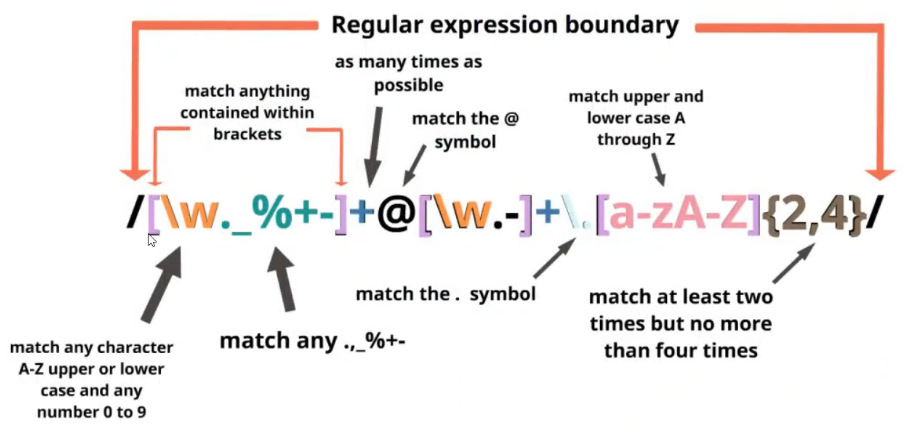

In [ ]:
Image('regex.png') if IN_COLAB else display(Image(filename='regex.png'))

L'espressione regolare ci dice **se la stringa è un indirizzo email, oppure no**.

Ecco la **spiegazione dei componenti** della espressione regolare di prima:

---

* `/ ... /`
  Delimitatori della regex.

---

Parte prima della @ (username)

* `[\w._%+-]+`

  * `[...]` → insieme di caratteri ammessi
  * `\w` → lettere + numeri + underscore
  * `._%+-` → altri simboli consentiti
  * `+` → uno o più caratteri

👉 Quindi: nome utente con uno o più caratteri validi.

---

**Simbolo centrale**

* `@`
  Deve essere presente esattamente una volta.

---

**Dominio**

* `[\w.-]+`

  * lettere/numeri + punto + trattino
  * `+` → uno o più caratteri

👉 Nome del dominio (es. `gmail`, `my-site`).

---

**Punto separatore**

* `\.`
  Il punto è “escapato” perché in regex normalmente significa “qualsiasi carattere”.

---

**Estensione (TLD)**

* `[a-zA-Z]{2,4}`

  * solo lettere
  * `{2,4}` → lunghezza tra 2 e 4 caratteri

👉 Esempi: `it`, `com`, `org`.

---

**Idee chiave della slide**

* Le **classi di caratteri** `[ ... ]` definiscono cosa è permesso
* I **quantificatori** (`+`, `{2,4}`) indicano quante volte
* I **caratteri speciali** (`\w`, `\.`) hanno significati specifici
* Le regex si leggono **da sinistra a destra come una grammatica compatta**


In [ ]:
import re

SYSLOG = re.compile(
    r"^(?P<mese>\w{3})\s+(?P<giorno>\d{1,2})\s+(?P<ora>\d{2}:\d{2}:\d{2})\s+"
    r"(?P<host>\S+)\s+(?P<processo>\S+?)(?:\[(?P<pid>\d+)\])?:\s+(?P<messaggio>.*)$"
)

for riga in leggi_righe("dati_oss/sistema.log"):
    m = SYSLOG.match(riga)
    if not m:
        print(f"  [saltata] {riga!r}")
        continue
    g = m.groupdict()
    print(f"{g['ora']} {g['host']:<6} {g['processo']:<8} {g['messaggio']}")


16:05:12 web01  sshd     Failed password for invalid user admin from 203.0.113.7 port 53122 ssh2
16:06:01 db01   kernel   Out of memory: Killed process 8123 (oracle)
16:06:05 web02  systemd  nginx.service: Failed with result 'exit-code'
  [saltata] '>>> riga che non rispetta il formato <<<'
16:07:00 web03  cron     (root) CMD (/usr/local/bin/backup.sh)


Vediamo in dettaglio cosa ha fatto la cella precedente.

**Perché una regex (e non `split`).** Una riga di syslog ha forma libera, con parti **opzionali** e a
posizione variabile: `mese giorno ora host processo[pid]: messaggio`. Il `[pid]` a volte c'è, a volte no;
il messaggio contiene spazi e due punti. Uno `split()` posizionale si romperebbe al primo caso diverso.
La regex cattura ogni campo per **come è fatto**, non per dove si trova, e gestisce nativamente le parti
opzionali.

**`re.compile(...)` e i gruppi nominati.** Compiliamo la regex **una volta sola** (più efficiente se la
usiamo su molte righe) e la conserviamo in `SYSLOG`. Dentro, ogni `(?P<nome>...)` è un **gruppo
nominato**: cattura una porzione di testo e le dà un'etichetta. I pezzi principali:

- `(?P<mese>\w{3})` — tre lettere (`Jun`); `(?P<giorno>\d{1,2})` — una o due cifre; `(?P<ora>\d{2}:\d{2}:\d{2})` — l'orario;
- `\s+` — uno o più spazi tra un campo e l'altro;
- `(?P<host>\S+)` — l'host (caratteri non-spazio); `(?P<processo>\S+?)` — il nome del processo (`\S+?`
  è "non-goloso": prende il minimo necessario);
- `(?:\[(?P<pid>\d+)\])?` — il `[pid]` reso **opzionale** dal `?` finale: il `(?:...)` raggruppa senza
  catturare, e cattura il numero solo se presente;
- `:\s+(?P<messaggio>.*)$` — i due punti, poi il messaggio fino a fine riga (`.*` = tutto il resto).

**Il ciclo: combacia o si salta.** Per ogni riga (lette in streaming dalla **stessa** `leggi_righe` del
JSONL — riuso!), proviamo `SYSLOG.match(riga)`:

- se **non** combacia (`if not m`) — come la riga-spazzatura `>>> ... <<<` — la **saltiamo** segnalandola,
  senza far esplodere nulla: stesso schema difensivo "salta e segnala" degli altri formati;
- se combacia, `m.groupdict()` restituisce un **dizionario** `{nome_gruppo: valore}` (`{"ora": "...",
  "host": "...", ...}`), pronto da usare. Lo stampiamo formattato.

> **Il punto da cogliere.** Tre formati, tre strumenti diversi — `json` per il JSONL, `csv` per il CSV,
> `re` per il syslog — ma **la stessa filosofia**: leggere in streaming (la `leggi_righe` è la medesima),
> catturare i campi in modo robusto, e saltare in modo esplicito ciò che non si interpreta. La regex è
> semplicemente l'attrezzo adatto quando il testo è libero e non ha una struttura su cui appoggiarsi.

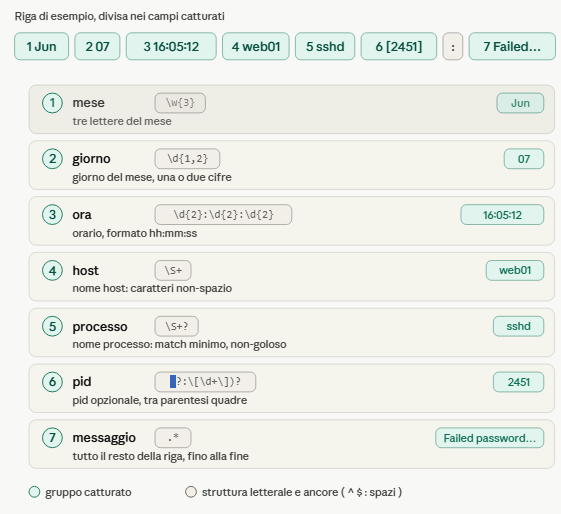

In [ ]:
Image('regex2.png') if IN_COLAB else display(Image(filename='regex2.png'))

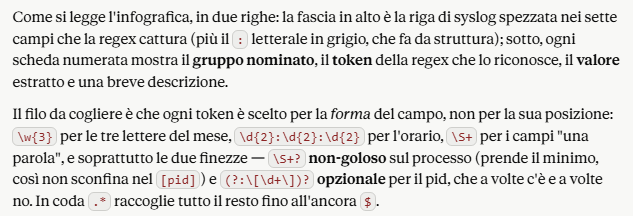

In [ ]:
Image('regex3.png') if IN_COLAB else display(Image(filename='regex3.png'))

# Ordinare nel tempo: timestamp, fusi, correlazione temporale (sezione 1.3)

Il timestamp è il **collante** fra sorgenti diverse, ma arriva in formati e fusi incoerenti: il JSONL
in ISO 8601 UTC, una metrica come *epoch*, un syslog in ora locale senza fuso. Prima di correlare
qualcosa nel tempo dobbiamo portare tutto a un **riferimento comune** (qui UTC). `zoneinfo` (libreria
standard) gestisce i fusi e l'ora legale: usarlo con `astimezone` è l'unico modo corretto, perché un
offset fisso (`+02:00`) sarebbe sbagliato metà dell'anno.

## Cos'è l'epoch

Il **tempo epoch** (detto anche *Unix time* o *POSIX time*) è un modo di rappresentare un istante come **un solo numero**: i secondi trascorsi da un istante di riferimento fisso, chiamato *the epoch*, che è la **mezzanotte UTC del 1° gennaio 1970**.

Quindi invece di scrivere una data "leggibile" come `2025-06-20 14:05:00`, l'epoch dice la stessa cosa con un numero:

```
1750428300
```

che significa "1.750.428.300 secondi dopo la mezzanotte del 1970", cioè esattamente quell'istante. Più precisamente è un conteggio di secondi in **UTC**: l'epoch non ha fuso orario, è un punto assoluto sulla linea del tempo.

Un dettaglio sul perché proprio il 1970: è la data in cui fu standardizzato Unix, e da lì il conteggio si è propagato a quasi tutti i sistemi informatici. È una convenzione, non una legge di natura — ma è universale.

## Perché esiste: i vantaggi

Rappresentare il tempo come un numero ha vantaggi enormi per le macchine, ed è il motivo per cui lo si trova ovunque nei log e nei database:

- **Calcolare le differenze è una sottrazione.** Quanti secondi separano due eventi? Basta sottrarre i due numeri. Con le date "leggibili" dovresti gestire mesi di lunghezza diversa, anni bisestili, cambi d'ora — un incubo. Con l'epoch: `t2 - t1`, e hai i secondi.
- **Ordinare gli eventi è ordinare numeri.** Il più piccolo è il più vecchio. Nessuna ambiguità.
- **È compatto e privo di ambiguità.** Un numero occupa poco, non ha problemi di formato (giorno/mese o mese/giorno?), non ha fuso orario da interpretare: è già un istante assoluto in UTC.

In pratica, l'epoch è il modo in cui i *computer* preferiscono pensare al tempo; le date leggibili sono la traduzione che facciamo *per noi*.

## Varianti che è bene conoscere

Una sottigliezza pratica, perché è una fonte tipica di bug: l'epoch si trova in **unità diverse**. La forma classica è in **secondi** (10 cifre, come `1750428300`), ma molti sistemi — JavaScript, parecchie API, alcuni database — lo esprimono in **millisecondi** (13 cifre, come `1750428300000`). Se interpreti dei millisecondi come secondi sbagli di un fattore mille, e l'istante finisce nell'anno 57000. La regola pratica per riconoscerli: un epoch in secondi *oggi* ha 10 cifre, in millisecondi ne ha 13.

In Python la conversione da epoch a data è diretta, e qui sta il punto importante per la cella: bisogna dichiarare che è UTC.

```python
  from datetime import datetime, timezone
  datetime.fromtimestamp(1750428300, tz=timezone.utc)
  # -> 2025-06-20 14:05:00+00:00
```

Il `tz=timezone.utc` non è un dettaglio: senza, `fromtimestamp` interpreterebbe il numero usando il **fuso locale della macchina**, dando un risultato diverso a seconda di dove gira il programma — uno dei bug più insidiosi nella gestione del tempo.

## Perché è citato nella cella

Torniamo al contesto. In quella cella il messaggio è che **lo stesso istante** arriva, da sorgenti diverse, in **tre vestiti diversi**:

- il JSONL lo scrive come stringa **ISO 8601** (`2025-06-20T14:05:00Z`) — leggibile, con il fuso esplicito (`Z` = UTC);
- una metrica lo scrive come **epoch** (`1750428300`) — il numero compatto che abbiamo appena visto;
- un syslog lo scrive come **ora locale senza fuso** (`2025-06-20 16:05:00`) — ambiguo, perché non dice in quale fuso è.

L'epoch è quindi uno dei tre formati che dobbiamo saper **riconoscere e convertire** per portare tutto a un riferimento comune (UTC) prima di correlare gli eventi nel tempo. È, tra i tre, il più "da macchina": non ha fuso da interpretare (è già UTC per definizione), il che lo rende in un certo senso il *meno* ambiguo dei tre — ma va comunque convertito in un oggetto data per allinearlo agli altri. Ed è anche il motivo per cui, nell'esempio della cella, l'epoch `1750428300` e le altre due rappresentazioni risultano *lo stesso istante*: sono tre scritture diverse dello stesso punto sulla linea del tempo.

In [ ]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

ROMA = ZoneInfo("Europe/Rome")

# Tre timestamp dalla stessa infrastruttura, in formati/fusi diversi: è lo STESSO istante
iso_utc = "2025-06-20T14:05:00Z"     # JSONL: ISO 8601 in UTC
epoch   = 1750428300                  # metrica: epoch (secondi dal 1970, UTC)
locale  = "2025-06-20 16:05:00"       # syslog: ora LOCALE (Europe/Rome), senza fuso

t1 = datetime.fromisoformat(iso_utc.replace("Z", "+00:00"))
t2 = datetime.fromtimestamp(epoch, tz=timezone.utc)
t3 = datetime.strptime(locale, "%Y-%m-%d %H:%M:%S").replace(tzinfo=ROMA).astimezone(timezone.utc)

for nome, dt in [("ISO 8601 (UTC)", t1), ("epoch", t2), ("locale Roma -> UTC", t3)]:
    print(f"{nome:22} -> {dt.isoformat()}")
print("\nStesso istante?", t1 == t2 == t3)


ISO 8601 (UTC)         -> 2025-06-20T14:05:00+00:00
epoch                  -> 2025-06-20T14:05:00+00:00
locale Roma -> UTC     -> 2025-06-20T14:05:00+00:00

Stesso istante? True


Con i tempi normalizzati possiamo fare il troubleshooting vero: la **correlazione temporale**.
Allineiamo due sorgenti diverse sullo stesso asse orario — gli **errori** del log applicativo e la
**latenza p95** delle metriche — e vediamo dove i picchi coincidono. È la differenza fra due flussi
scollegati e un'unica storia dell'incidente.

# Correlazione temporale: allineare due sorgenti sullo stesso asse orario

La seguente cella mette a confronto due sorgenti diverse — gli **errori** del log applicativo
e la **latenza p95** delle metriche — riportandole sullo **stesso asse orario** e affiancandole in
un'unica tabella. Conta gli errori per ora, li allinea con la p95 per ora, e stampa la finestra intorno
all'incidente: dove le due colonne salgono **insieme**, abbiamo la conferma che il picco di latenza e
l'ondata di errori sono lo stesso evento.

In [ ]:
import pandas as pd

df_log = pd.DataFrame(eventi)
df_log["ts"] = pd.to_datetime(df_log["ts"], utc=True)            # tz-aware UTC

errori_ora = (df_log[df_log["livello"] == "ERROR"]
              .set_index("ts").resample("h").size().rename("n_errori"))
p95_ora = metriche.set_index("ts")["p95_ms"]

allineato = pd.concat([p95_ora, errori_ora], axis=1).fillna(0)
allineato["n_errori"] = allineato["n_errori"].astype(int)

print("Finestra intorno all'incidente del 07-06 (UTC):")
print(allineato.loc["2025-06-07 14:00":"2025-06-07 19:00"])


Finestra intorno all'incidente del 07-06 (UTC):
                           p95_ms  n_errori
ts                                         
2025-06-07 14:00:00+00:00     608         0
2025-06-07 15:00:00+00:00     520         0
2025-06-07 16:00:00+00:00    1850        13
2025-06-07 17:00:00+00:00     602         0
2025-06-07 18:00:00+00:00     556         0
2025-06-07 19:00:00+00:00     575         0


Vediamo in dettaglio cosa fa la cella precedente.

**Dal log a una tabella con il tempo come indice.** Gli `eventi` (i dizionari letti dal JSONL) diventano
un DataFrame, e la colonna `ts` viene convertita in veri oggetti data/ora con `pd.to_datetime(...,
utc=True)`. Il `utc=True` è cruciale: rende i timestamp **tz-aware in UTC**, lo stesso riferimento delle
metriche — è la normalizzazione di cui parlavamo, senza la quale l'allineamento sarebbe falsato.

**Contare gli errori per ora (`errori_ora`).** Tre operazioni in catena:

- `df_log[df_log["livello"] == "ERROR"]` — tiene **solo** le righe di errore (una maschera booleana);
- `.set_index("ts")` — promuove il timestamp a **indice** del DataFrame: è il prerequisito per ragionare
  sul tempo;
- `.resample("h").size()` — `resample("h")` raggruppa per **ora** (è il `groupby` delle serie temporali),
  e `.size()` conta quante righe cadono in ciascun secchio orario. Il risultato è "quanti errori per ora",
  rinominato `n_errori`.

**La p95 per ora (`p95_ora`).** Le metriche sono **già** orarie, quindi basta mettere `ts` come indice ed
estrarre la colonna `p95_ms`. Ora le due serie — errori e latenza — condividono lo **stesso tipo di
indice**: un orario UTC.

**Affiancarle (`allineato`).** `pd.concat([...], axis=1)` unisce le due serie **per colonna**, allineandole
**sull'indice**: pandas accosta i valori che hanno la stessa ora, riga per riga. Due ritocchi per pulizia:
`.fillna(0)` mette 0 dove una serie non ha valori (le ore senza errori risultano vuote nel conteggio), e
`.astype(int)` riporta i conteggi a numeri interi (il `concat` con i NaN li aveva resi decimali).

**Leggere il risultato.** `allineato.loc["2025-06-07 14:00":"2025-06-07 19:00"]` ritaglia la **finestra
oraria** intorno all'incidente (l'indicizzazione per intervallo di tempo è uno dei superpoteri di pandas
sulle serie temporali). Nell'output, le 16:00 e le 17:00 spiccano su **entrambe** le colonne: p95 altissima
*e* molti errori, mentre le altre ore restano basse e a zero errori.

> **Il punto da cogliere.** La correlazione temporale è proprio questo: due flussi nati separati (un log
> applicativo e una serie di metriche) vengono portati sullo stesso asse orario e **affiancati**, finché la
> coincidenza dei picchi racconta una storia sola. È l'essenza del troubleshooting — *"questo coincide con
> quello?"* — resa concreta in poche righe di pandas. E tutto regge su un presupposto: aver normalizzato i
> tempi a UTC *prima* di allinearli.

# Correlazioni tra KPI

La correlazione temporale risponde a *"quando?"*. La **correlazione tra KPI** risponde a *"cosa si
muove insieme a cosa?"*. La **correlazione di Pearson** mette un numero su questa intuizione, da
**−1 a +1**: +1 = si muovono insieme nella stessa direzione, 0 = nessuna relazione lineare, −1 =
direzioni opposte. In pandas, `.corr()` la calcola per **tutte le coppie** di colonne numeriche.

In [ ]:
kpi = ["req_per_min", "cpu_pct", "p95_ms", "error_rate", "mem_pct"]
pearson = metriche[kpi].corr()                 # correlazione di Pearson (default)
print(pearson.round(2))


             req_per_min  cpu_pct  p95_ms  error_rate  mem_pct
req_per_min         1.00     0.98    0.82        0.83     0.08
cpu_pct             0.98     1.00    0.81        0.85     0.08
p95_ms              0.82     0.81    1.00        0.89     0.12
error_rate          0.83     0.85    0.89        1.00     0.12
mem_pct             0.08     0.08    0.12        0.12     1.00


Una **heatmap** rende la matrice leggibile a colpo d'occhio: il blu intenso segnala le coppie
fortemente correlate, il bianco l'assenza di relazione.

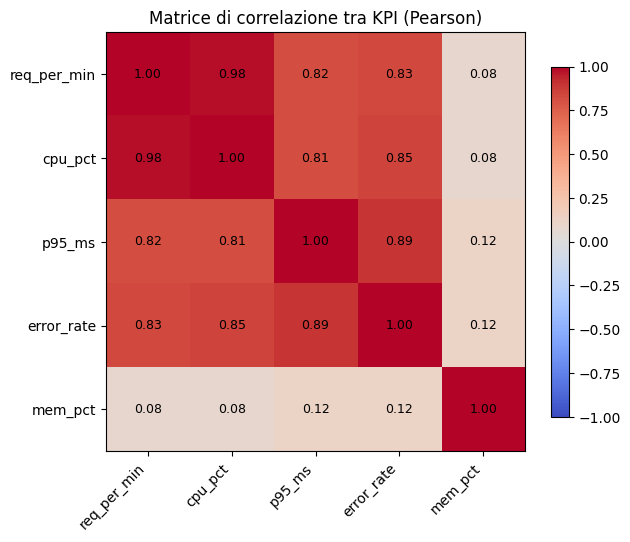

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(pearson.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(kpi))); ax.set_xticklabels(kpi, rotation=45, ha="right")
ax.set_yticks(range(len(kpi))); ax.set_yticklabels(kpi)
for i in range(len(kpi)):
    for j in range(len(kpi)):
        ax.text(j, i, f"{pearson.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matrice di correlazione tra KPI (Pearson)")
plt.tight_layout(); plt.show()


Cosa leggiamo: `req_per_min`, `cpu_pct`, `p95_ms` ed `error_rate` sono **fortemente correlati**
fra loro — la catena del sistema sotto carico (più richieste → più CPU → più latenza → più errori).
`mem_pct` è invece **scollegato** da tutto (correlazioni ≈ 0): riconoscere una *non*-correlazione è
prezioso quanto trovarne una, perché ci dice dove **non** cercare la causa. Visualizziamo la coppia
più forte.

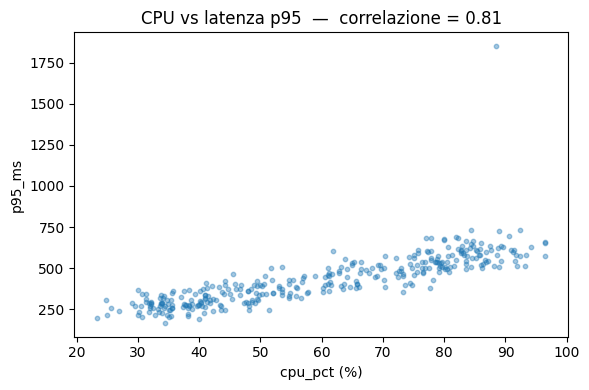

In [ ]:
r = metriche["cpu_pct"].corr(metriche["p95_ms"])
plt.figure(figsize=(6, 4))
plt.scatter(metriche["cpu_pct"], metriche["p95_ms"], s=10, alpha=0.4)
plt.xlabel("cpu_pct (%)"); plt.ylabel("p95_ms")
plt.title(f"CPU vs latenza p95  —  correlazione = {r:.2f}")
plt.tight_layout(); plt.show()


### Pearson non basta: la forma della relazione

Due cautele importanti. **Pearson misura solo le relazioni lineari.** La relazione CPU→latenza qui è
*curva* (l'impennata quando la CPU è alta): Pearson la sottostima. La correlazione di **Spearman**, che
si basa sui *ranghi* (sull'ordine, non sui valori), coglie qualsiasi relazione **monotona**, anche non
lineare — e infatti sulla coppia CPU/p95 risulta più alta. Confrontarle è un indizio della *forma* del
legame.

In [ ]:
p = metriche["cpu_pct"].corr(metriche["p95_ms"], method="pearson")
s = metriche["cpu_pct"].corr(metriche["p95_ms"], method="spearman")
print(f"CPU vs p95  ->  Pearson: {p:.2f}   Spearman: {s:.2f}")
print("Spearman piu' alto = relazione monotona ma non perfettamente lineare (la 'curva').")


CPU vs p95  ->  Pearson: 0.81   Spearman: 0.90
Spearman piu' alto = relazione monotona ma non perfettamente lineare (la 'curva').


### Correlazione con ritardo: un KPI ne anticipa un altro?

La correlazione "classica" confronta i KPI allo **stesso istante**. Ma nel troubleshooting conta anche
la **precedenza**: la CPU sale *prima* che la latenza peggiori? Spostiamo una serie nel tempo (`shift`)
e misuriamo la correlazione a ogni *lag*: il lag con la correlazione massima ci dice di quanto un KPI
**anticipa** l'altro. È la **cross-correlazione**.

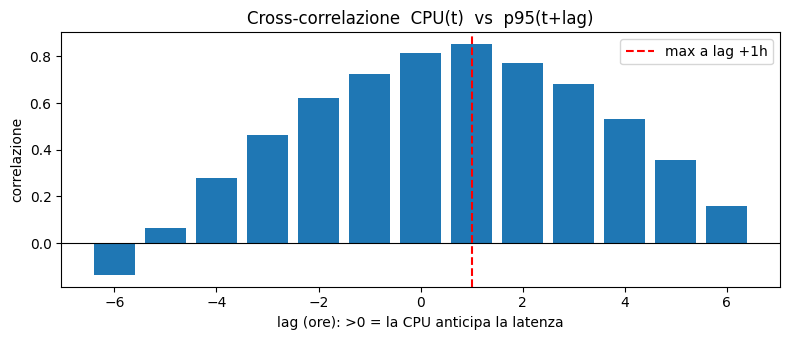

Correlazione massima al lag +1 ore: la CPU anticipa la latenza di ~1 h.


In [ ]:
import matplotlib.pyplot as plt

cpu_s = metriche["cpu_pct"]
p95_s = metriche["p95_ms"]
# corr( cpu(t), p95(t+k) ): se la CPU anticipa, il massimo è a k > 0
lags = range(-6, 7)
cc = [cpu_s.corr(p95_s.shift(-k)) for k in lags]
lag_max = list(lags)[int(np.argmax(cc))]

plt.figure(figsize=(8, 3.5))
plt.bar(list(lags), cc)
plt.axvline(lag_max, color="red", linestyle="--", label=f"max a lag {lag_max:+d}h")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Cross-correlazione  CPU(t)  vs  p95(t+lag)")
plt.xlabel("lag (ore): >0 = la CPU anticipa la latenza"); plt.ylabel("correlazione")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Correlazione massima al lag {lag_max:+d} ore: la CPU anticipa la latenza di ~{lag_max} h.")


**Avvertenza d'obbligo: correlazione non è causalità.** Due KPI correlati possono salire insieme
perché uno causa l'altro, *oppure* perché una terza variabile (qui il volume di richieste) li muove
entrambi. E anche un *anticipo* nel tempo è un indizio, non una prova. La correlazione dice **dove
guardare**, non **chi è la causa**: resta un punto di partenza per l'indagine, non la sua conclusione.

## L'auto-correlazione: una metrica e il proprio passato

Finora abbiamo correlato KPI *diversi*. L'**autocorrelazione** correla una serie **con sé stessa**,
spostata indietro di un certo numero di passi (il *lag*): risponde a *"il valore di adesso somiglia a
quello di N ore fa?"*. È lo strumento per scoprire i **ritmi ricorrenti**. Se un sistema ha un ciclo
giornaliero, il valore delle 15 di oggi somiglia a quello delle 15 di ieri: ci aspettiamo
un'autocorrelazione alta a un lag di 24 ore. Lo verifichiamo sul volume di richieste, `req_per_min`,
calcolando l'autocorrelazione per tutti i lag da 1 a 48 ore — il **correlogramma** (ACF).

In [ ]:
import matplotlib.pyplot as plt

serie = metriche["req_per_min"]                 # già in ordine orario
lags = range(1, 49)
acf = [serie.autocorr(l) for l in lags]         # autocorrelazione a ogni lag

print(f"autocorrelazione a lag  1 ora : {serie.autocorr(1):.2f}   (ore adiacenti)")
print(f"autocorrelazione a lag 12 ore : {serie.autocorr(12):.2f}   (mezza giornata: in opposizione)")
print(f"autocorrelazione a lag 24 ore : {serie.autocorr(24):.2f}   (un giorno: molto simile)")

plt.figure(figsize=(9, 3.5))
plt.bar(list(lags), acf)
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(24, color="red", linestyle="--", label="lag 24h (un giorno)")
plt.axvline(48, color="red", linestyle=":", label="lag 48h (due giorni)")
plt.title("Autocorrelazione di req_per_min per lag (ACF)")
plt.xlabel("lag (ore)")
plt.ylabel("autocorrelazione")
plt.legend()
plt.tight_layout()
plt.show()

I picchi a **24 e 48 ore** confermano numericamente il ritmo giornaliero; a **lag 12** l'autocorrelazione
è invece negativa (giorno contro notte, in opposizione di fase). Due conseguenze pratiche per il
monitoraggio: le **soglie vanno rese consapevoli del tempo** (un valore normale a mezzogiorno è
un'anomalia alle 4 del mattino), e un'**anomalia si riconosce come rottura del ritmo**, quando una
metrica ciclica smette di seguire il suo schema abituale. È il ponte verso le baseline e il rilevamento
di anomalie, l'evoluzione delle soglie a numero fisso del primo strumento.

> Cross-correlazione e autocorrelazione sono parenti — entrambe spostano la serie nel tempo — ma
> rispondono a domande diverse: *"questo KPI **anticipa** quell'altro?"* la prima, *"questo KPI ha un
> **ritmo** che si ripete?"* la seconda.

# Attingere ai database (Oracle / SQL Server) (sezione 2.1)

Nella realtà le metriche vivono su un database. In Python l'accesso segue lo **standard DB-API 2.0**:
`connect → cursor → execute → fetch`. Imparato una volta, vale per SQLite, Oracle e SQL Server — cambia
solo la connessione. Regola ferrea: i valori passano come **parametri** (segnaposto `?`), mai
concatenati nella stringa SQL (sicurezza, niente *injection*). Avvolgiamo il pattern in una **funzione
riutilizzabile** che restituisce un DataFrame — l'I/O confinato in un punto solo, come nel Modulo 1.1.

In [ ]:
import sqlite3
import pandas as pd

# Salviamo le metriche nel database (lo creiamo da zero)
con = sqlite3.connect("oss.db")
metriche.to_sql("metriche", con, if_exists="replace", index=False)
con.close()

def interroga(percorso_db: str, sql: str, parametri: tuple = ()) -> pd.DataFrame:
    """Esegue una query parametrizzata e restituisce un DataFrame. L'I/O sta tutto qui."""
    with sqlite3.connect(percorso_db) as con:          # context manager: chiusura garantita
        return pd.read_sql(sql, con, params=parametri)

# Le ore con latenza oltre soglia (valore passato come PARAMETRO, non concatenato)
critiche = interroga(
    "oss.db",
    "SELECT ts, cpu_pct, p95_ms FROM metriche WHERE p95_ms > ? ORDER BY p95_ms DESC LIMIT 5",
    (800,),
)
print(critiche.to_string(index=False))


                       ts  cpu_pct  p95_ms
2025-06-07 16:00:00+00:00     88.5    1850


Lo stesso codice gira su Oracle e SQL Server: cambia **solo** la connessione (riferimento, non
eseguibile qui). La funzione `interroga` resterebbe identica, ricevendo la connessione giusta.

```python
# Oracle: oracledb in "thin mode" (nessun client Oracle da installare)
import oracledb
con = oracledb.connect(user="utente", password="segreta", dsn="host:1521/servizio")
# segnaposto Oracle:  ... WHERE p95_ms > :soglia   ->  cur.execute(sql, soglia=800)

# SQL Server: pyodbc
import pyodbc
con = pyodbc.connect("DRIVER={ODBC Driver 18 for SQL Server};SERVER=host;"
                     "DATABASE=metriche;UID=utente;PWD=segreta")
# segnaposto SQL Server: ?  (come SQLite)
```

Le credenziali non vanno mai cablate nel codice: si leggono da variabili d'ambiente o da un file di
configurazione. E su Oracle/SQL Server, in produzione, pandas usa di solito un *engine* SQLAlchemy come
ponte più robusto.

# Chiudere il cerchio con Splunk (sezione 3.2)

Splunk è il collettore centrale. Python lo usa in **due direzioni**.

**Estrarre (pull).** Una ricerca SPL via REST restituisce JSON: lo parsiamo con gli **stessi** strumenti
del 1.2 (`json`) e otteniamo subito record. Simuliamo la risposta della ricerca
`index=app status>=500 | stats count by host`, e la confrontiamo con ciò che vediamo nei nostri log.

In [ ]:
import json
import pandas as pd

# Risposta JSON di una ricerca Splunk via REST (output_mode=json), simulata
risposta_splunk = """
{"preview": false, "results": [
  {"host": "web01", "count": "12"},
  {"host": "web02", "count": "73"},
  {"host": "web03", "count": "9"}
]}
"""
dati = json.loads(risposta_splunk)                     # JSON -> Python, come nel 1.2
df_splunk = pd.DataFrame(dati["results"])
df_splunk["count"] = df_splunk["count"].astype(int)    # Splunk restituisce i numeri come stringhe
df_splunk = df_splunk.sort_values("count", ascending=False)
print(df_splunk.to_string(index=False))
print("\nHost con più errori secondo Splunk:", df_splunk.iloc[0]["host"])

# In produzione la chiamata REST sarebbe (riferimento, non eseguito):
#   import requests
#   r = requests.get("https://splunk:8089/services/search/jobs/<sid>/results",
#                    headers={"Authorization": "Bearer <TOKEN>"},
#                    params={"output_mode": "json"}, timeout=10)
#   dati = r.json()


 host  count
web02     73
web01     12
web03      9

Host con più errori secondo Splunk: web02


**Inviare (push).** Con l'HEC (HTTP Event Collector) mandiamo a Splunk una metrica calcolata da
noi — ad esempio l'alert sull'incidente. Costruiamo il payload nel formato HEC; l'invio reale
(commentato) è una semplice `POST` autenticata con un token.

In [ ]:
import json, time

# Prendiamo dal nostro DataFrame il momento peggiore e ne facciamo un evento per Splunk
peggiore = metriche.loc[metriche["p95_ms"].idxmax()]
evento_hec = {
    "time": int(time.time()),
    "sourcetype": "monitor:p95",
    "event": {
        "ts_incidente": peggiore["ts"].isoformat(),
        "metrica": "p95_ms", "valore": int(peggiore["p95_ms"]),
        "error_rate": float(peggiore["error_rate"]), "stato": "CRITICO",
    },
}
print(json.dumps(evento_hec, indent=2, ensure_ascii=False))

# Invio reale (riferimento, non eseguito):
#   import requests
#   requests.post("https://splunk.azienda.it:8088/services/collector",
#                 headers={"Authorization": "Splunk <TOKEN-HEC>"},
#                 json=evento_hec, timeout=5)


{
  "time": 1782332435,
  "sourcetype": "monitor:p95",
  "event": {
    "ts_incidente": "2025-06-07T16:00:00+00:00",
    "metrica": "p95_ms",
    "valore": 1850,
    "error_rate": 0.42,
    "stato": "CRITICO"
  }
}


# In sintesi

Abbiamo seguito un dato lungo l'intera catena dell'osservabilità, **analizzandolo** lungo il percorso:

- **1.2** — un *lettore ai bordi* che da JSONL (anche compresso), CSV e log non strutturati produce
  record puliti, in streaming e in modo difensivo;
- **1.3** — la **normalizzazione temporale** (formati e fusi a un riferimento comune) e la
  **correlazione temporale** che allinea le sorgenti e fa emergere l'incidente;
- **Correlazioni tra KPI** — `.corr()`, heatmap, Pearson vs Spearman per leggere la *forma* del legame,
  e la **cross-correlazione** per scoprire quale KPI ne anticipa un altro — sempre con la regola d'oro
  *correlazione ≠ causalità*;
- **2.1** — il pattern **DB-API 2.0** avvolto in una funzione riutilizzabile, identico su SQLite, Oracle
  e SQL Server, con query parametrizzate;
- **3.2** — **Splunk** come collettore: ne estraiamo i risultati (JSON → gli strumenti del 1.2) e gli
  inviamo metriche via HEC.

Lo scheletro è sempre quello del Modulo 1.1: *acquisire ai bordi → elaborare con strumenti dedicati*.
Ogni pezzo è una funzione con un compito chiaro, e questo è ciò che li rende componibili in strumenti
operativi reali.